In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import os

# ✅ Fixed seed
torch.manual_seed(42)
np.random.seed(42)

mlflow.set_experiment("ecg-ssl-pretraining")

2026/05/18 08:03:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 08:03:59 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 08:03:59 INFO mlflow.tracking.fluent: Experiment with name 'ecg-ssl-pretraining' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Applications/AI/ecg-ssl-research-final/mlruns/1', creation_time=1779071639270, experiment_id='1', last_update_time=1779071639270, lifecycle_stage='active', name='ecg-ssl-pretraining', tags={}, trace_location=None, workspace='default'>

In [2]:
PRETRAIN_RUN_NAME = "conv1d-mask30-lr1e3"

if mlflow.active_run() is not None:
    mlflow.end_run()

mlflow.start_run(run_name=PRETRAIN_RUN_NAME)
print(f"MLflow run started: {mlflow.active_run().info.run_id}")


MLflow run started: f6070ce95ba94f739e84019e2e73bb9f


In [3]:
# ✅ Load the already-normalized data saved by Preprocessing notebook
X = np.load("./ecg_ssl_research/data/processed/X.npy")

print("X shape:", X.shape)
print("Mean of sample 0:", X[0].mean().round(4))   # should be ~0
print("Std  of sample 0:", X[0].std().round(4))    # should be ~1

X shape: (84708, 180)
Mean of sample 0: 0.0
Std  of sample 0: 1.0


In [4]:
class ECGPretrainDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]

In [5]:
dataset    = ECGPretrainDataset(X)

# ✅ 90% train, 10% val — so we can track if encoder overfits
val_size   = int(0.1 * len(dataset))
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)

print(f"Pretrain train size: {train_size}")
print(f"Pretrain val   size: {val_size}")

Pretrain train size: 76238
Pretrain val   size: 8470


In [6]:
def mask_signal(x, mask_ratio=0.3, block_size=5):
    """
    Zero Python loops — pure tensor operations
    Fastest possible version
    """
    batch, length = x.shape
    num_blocks    = int((length * mask_ratio) / block_size)

    # starts: (batch, num_blocks)
    starts = torch.randint(0, length - block_size, (batch, num_blocks))

    # offsets: (1, 1, block_size)
    offsets = torch.arange(block_size).view(1, 1, block_size)

    # indices: (batch, num_blocks, block_size)
    indices = (starts.unsqueeze(-1) + offsets).clamp(0, length - 1)

    # flatten to (batch, num_blocks * block_size)
    indices = indices.view(batch, -1)

    # build mask
    mask = torch.zeros(batch, length, dtype=torch.bool)
    mask.scatter_(1, indices, True)

    x_masked = x.clone()
    x_masked[mask] = 0

    return x_masked, mask

In [7]:
class ECGAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ✅ BatchNorm added after each Conv layer for stable training
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 2, stride=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.ConvTranspose1d(64, 32, 2, stride=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 1, 3, padding=1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded.squeeze(1)

In [8]:
def masked_loss(pred, target, mask):
    """
    Only compute loss on masked positions.
    This forces the model to reconstruct what was hidden.
    """
    return ((pred - target) ** 2 * mask).sum() / (mask.sum() + 1e-8)

In [9]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = ECGAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ✅ ReduceLROnPlateau on validation loss
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print(f"Training on: {device}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Training on: cpu
Total params: 56,577


In [10]:
epochs        = 50
best_val_loss = float('inf')
patience      = 10
counter       = 0
mask_ratio    = 0.3
block_size    = 5

mlflow.log_params({
    "mask_ratio": mask_ratio,
    "block_size": block_size,
    "learning_rate": 0.001,
    "batch_size": 128,
    "epochs": epochs,
    "window_size": X.shape[1],
    "architecture": "Conv1D-Autoencoder",
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    "patience": patience,
    "dataset": "MIT-BIH",
    "n_train_samples": train_size,
    "n_val_samples": val_size
})

for epoch in range(epochs):

    # ========================
    # TRAINING PHASE
    # ========================
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch    = batch.to(device)
        masked_x, mask = mask_signal(batch, mask_ratio=mask_ratio, block_size=block_size)
        masked_x = masked_x.to(device)
        mask     = mask.to(device)

        outputs  = model(masked_x)
        loss     = masked_loss(outputs, batch, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ========================
    # VALIDATION PHASE
    # ========================
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch    = batch.to(device)
            masked_x, mask = mask_signal(batch, mask_ratio=mask_ratio, block_size=block_size)
            masked_x = masked_x.to(device)
            mask     = mask.to(device)

            outputs  = model(masked_x)
            loss     = masked_loss(outputs, batch, mask)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    current_lr   = optimizer.param_groups[0]['lr']

    # ✅ Step on validation loss
    scheduler.step(avg_val_loss)

    mlflow.log_metrics({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "lr": current_lr
    }, step=epoch + 1)

    print(f"Epoch {epoch+1:>3} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"LR: {current_lr:.2e}")

    # ========================
    # EARLY STOPPING
    # ========================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        os.makedirs("./models", exist_ok=True)
        torch.save(model.encoder.state_dict(), "./models/pretrained_encoder.pth")
        print("  ✅ Val loss improved → encoder saved")
    else:
        counter += 1
        print(f"  ⚠️  No improvement for {counter}/{patience} epochs")
        if counter >= patience:
            print("  🛑 Early stopping triggered!")
            break


Epoch   1 | Train Loss: 0.0733 | Val Loss: 0.0459 | LR: 1.00e-03
  ✅ Val loss improved → encoder saved
Epoch   2 | Train Loss: 0.0433 | Val Loss: 0.0390 | LR: 1.00e-03
  ✅ Val loss improved → encoder saved
Epoch   3 | Train Loss: 0.0378 | Val Loss: 0.0347 | LR: 1.00e-03
  ✅ Val loss improved → encoder saved
Epoch   4 | Train Loss: 0.0351 | Val Loss: 0.0348 | LR: 1.00e-03
  ⚠️  No improvement for 1/10 epochs
Epoch   5 | Train Loss: 0.0324 | Val Loss: 0.0348 | LR: 1.00e-03
  ⚠️  No improvement for 2/10 epochs
Epoch   6 | Train Loss: 0.0324 | Val Loss: 0.0344 | LR: 1.00e-03
  ✅ Val loss improved → encoder saved
Epoch   7 | Train Loss: 0.0312 | Val Loss: 0.0329 | LR: 1.00e-03
  ✅ Val loss improved → encoder saved
Epoch   8 | Train Loss: 0.0305 | Val Loss: 0.0365 | LR: 1.00e-03
  ⚠️  No improvement for 1/10 epochs
Epoch   9 | Train Loss: 0.0306 | Val Loss: 0.0293 | LR: 1.00e-03
  ✅ Val loss improved → encoder saved
Epoch  10 | Train Loss: 0.0286 | Val Loss: 0.0267 | LR: 1.00e-03
  ✅ Val los

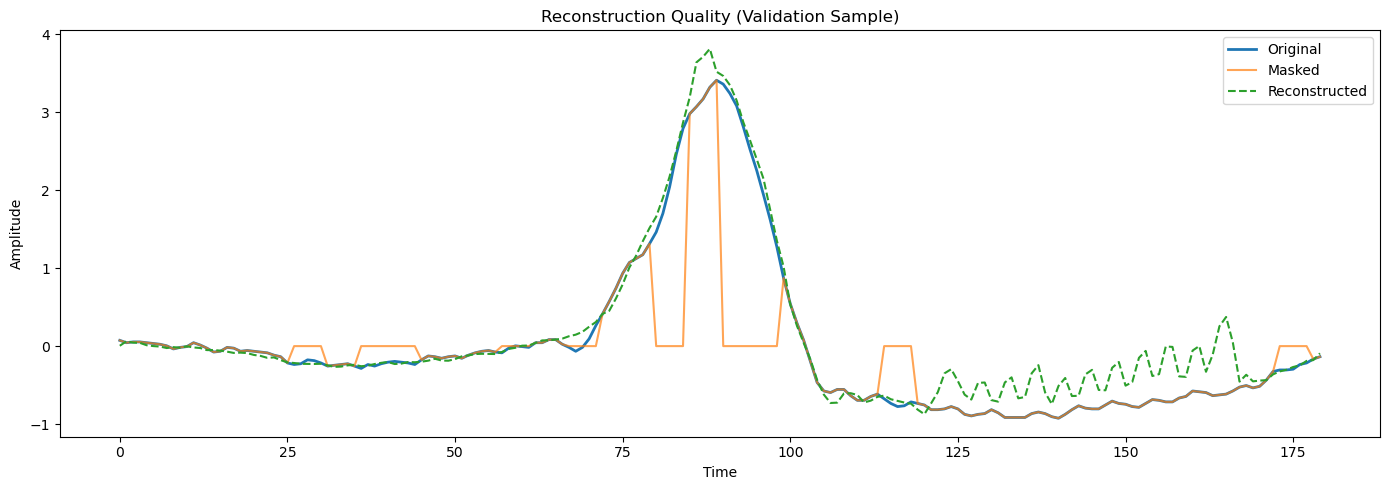

In [11]:
model.eval()

sample   = next(iter(val_loader))[:1].to(device)
masked_x, mask = mask_signal(sample, mask_ratio=mask_ratio, block_size=block_size)
masked_x = masked_x.to(device)

with torch.no_grad():
    recon = model(masked_x)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample[0].cpu(),   label="Original",      linewidth=2)
ax.plot(masked_x[0].cpu(), label="Masked",        alpha=0.7)
ax.plot(recon[0].cpu(),    label="Reconstructed", linestyle="--")
ax.set_title("Reconstruction Quality (Validation Sample)")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
ax.legend()
fig.tight_layout()

artifact_dir = "./mlflow_artifacts"
os.makedirs(artifact_dir, exist_ok=True)
reconstruction_plot_path = os.path.join(artifact_dir, "pretraining_reconstruction.png")
fig.savefig(reconstruction_plot_path, bbox_inches="tight")
mlflow.log_artifact(reconstruction_plot_path)
plt.show()


In [12]:
os.makedirs("./models", exist_ok=True)

encoder_weights_path = "./models/pretrained_encoder.pth"
autoencoder_weights_path = "./models/pretrained_autoencoder_full.pth"

torch.save(model.encoder.state_dict(), encoder_weights_path)
print("✅ Encoder saved")

torch.save(model.state_dict(), autoencoder_weights_path)
print("✅ Full autoencoder saved")

try:
    mlflow.pytorch.log_model(
        model.encoder,
        artifact_path="ecg_encoder",
        registered_model_name="ECG-SSL-Encoder"
    )
except Exception as exc:
    print(f"Model registry unavailable ({exc}). Logging encoder without registration.")
    mlflow.pytorch.log_model(model.encoder, artifact_path="ecg_encoder")

mlflow.log_artifact(encoder_weights_path)
mlflow.log_artifact(autoencoder_weights_path)
print(f"Run ID: {mlflow.active_run().info.run_id}")


2026/05/18 08:34:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 08:34:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


✅ Encoder saved
✅ Full autoencoder saved
Run ID: f6070ce95ba94f739e84019e2e73bb9f


Successfully registered model 'ECG-SSL-Encoder'.
Created version '1' of model 'ECG-SSL-Encoder'.


In [13]:
if mlflow.active_run() is not None:
    mlflow.end_run()
    print("MLflow run closed.")


MLflow run closed.
